---

# 🌳 Decision Tree Classification (Karar Ağacı ile Sınıflandırma)

---

## 📌 Tanım:

**Decision Tree Classifier**, verileri **karar kurallarına göre dallara ayırarak** sınıflandırma yapan bir algoritmadır.

> ❓"Yaş < 30 mu?" → Evetse bir sınıfa, hayırsa diğer sınıfa gönder.
> ❓"Gelir > 50K mı?" → Evetse X sınıfı, değilse Y.

Bu şekilde **ağaç benzeri** bir yapı oluşturur.

---

## 🧠 Nasıl Çalışır?

1. **En iyi ayıran özelliği** bulur (örneğin: "yaş")
2. Veriyi bu özelliğe göre iki gruba ayırır
3. Her grupta tekrar en iyi ayıran özelliği bulur
4. Bu işlem yapraklara ulaşılana kadar devam eder

Her **yaprak (leaf)**, bir sınıf etiketine karşılık gelir.

---

## 📊 Örnek (Kredi Onayı):

| Yaş | Gelir | Kredi Durumu |
| --- | ----- | ------------ |
| 25  | 30K   | Red (0)      |
| 40  | 60K   | Onay (1)     |
| 50  | 45K   | Onay (1)     |
| 23  | 25K   | Red (0)      |

**Ağaç Şekli:**

```
            Yaş < 35?
           /         \
        Evet          Hayır
       /                \
   Gelir < 28K?       Onay
   /        \
Red         Onay
```

---

## 🧮 Karar Bölmeleri (Split):

Her bölünme işlemi için şu kriterler kullanılır:

| Kriter                         | Açıklama                                         |
| ------------------------------ | ------------------------------------------------ |
| **Gini Impurity**              | Veri saf mı? (daha çok tercih edilir sklearn’de) |
| **Entropy / Information Gain** | Bilgi kazanımı ile karar verilir                 |

---

## ✅ Avantajları:

| Avantaj           | Açıklama                                |
| ----------------- | --------------------------------------- |
| Görselleştirme    | Ağaç yapısı çok net gösterilebilir      |
| Yorumlanabilirlik | Karar kuralları açıkça anlaşılır        |
| Feature selection | Hangi özellik önemli otomatik öğrenilir |
| Önişleme gerekmez | Normalizasyon, ölçekleme gerekmez       |

---

## ⚠️ Dezavantajları:

| Sorun                       | Açıklama                                                   |
| --------------------------- | ---------------------------------------------------------- |
| Aşırı öğrenme (overfitting) | Ağaç çok derinleşirse → tüm veriyi ezberleyebilir          |
| Kararsızlık                 | Küçük veri değişikliği → ağacın yapısı tamamen değişebilir |

Bu yüzden bazı sınırlar konur:

* `max_depth` → Ağacın maksimum derinliği
* `min_samples_split` → Dal oluşturmak için gereken minimum veri sayısı

---

## 💻 Python Örneği:

```python
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
```

Görselleştirmek için:

```python
from sklearn import tree
tree.plot_tree(classifier)
```

---

## 🎯 Naive Bayes vs Decision Tree:

| Özellik               | Naive Bayes | Decision Tree            |
| --------------------- | ----------- | ------------------------ |
| Olasılıksal mı?       | Evet        | Hayır                    |
| Bağımsızlık varsayımı | Var         | Yok                      |
| Yorumlanabilirlik     | Zor         | Çok kolay (if–else gibi) |
| Karmaşık yapı         | Kötü        | İyi                      |

---

## 🎓 Özetle:

* **Decision Tree**, verileri dallara ayırarak sınıflandırır.
* Hangi özellikle nasıl bölüneceğini otomatik bulur.
* En anlaşılır, şeffaf algoritmalardandır.
* Ancak **aşırı öğrenme (overfitting)** riski taşır — kontrol edilmesi gerekir.

---

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [3]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Decision Tree Classification model on the Training set

In [8]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [9]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


## Predicting the Test set results

In [11]:
y_pred = classifier.predict(X_test) # sağdaki gerçek değer soldaki modelin tahmini
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


## Making the Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[62  6]
 [ 3 29]]


0.91

## Visualising the Training set results

C:\Users\523579\AppData\Local\Temp\ipykernel_39004\4121786435.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


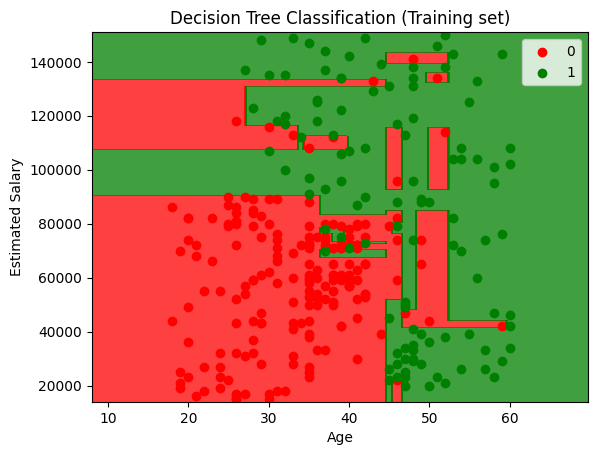

In [13]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results

C:\Users\523579\AppData\Local\Temp\ipykernel_39004\1703921148.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


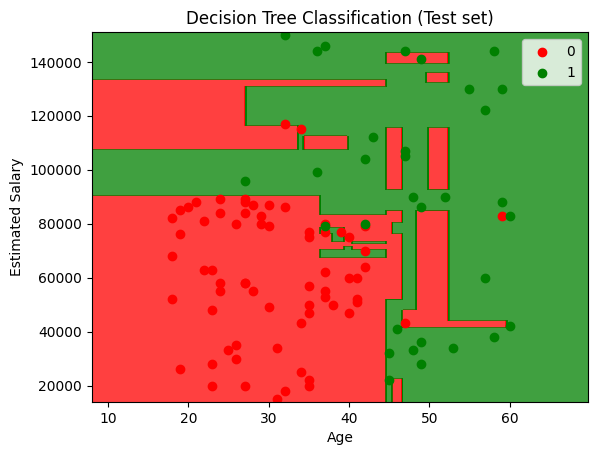

In [14]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()